<a href="https://colab.research.google.com/github/Destakka/Inception-Xception-Hybrid/blob/xception/done_Xception_Done_Dengan_SMOTE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers as L
from tensorflow.keras import regularizers
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, log_loss, classification_report


In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Load dataset
file_path = '/content/drive/MyDrive/ai/healthcare-dataset-stroke-data.csv'
df = pd.read_csv(file_path)

In [ ]:
# Converting categorical features to numeric using LabelEncoder
categorical_cols = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']
le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

# Handling numerical features separately
numerical_cols = ['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi']


In [ ]:
# Imputing missing values
imputer = SimpleImputer(strategy='mean')
df[numerical_cols] = imputer.fit_transform(df[numerical_cols])

# Normalizing numerical features
scaler = StandardScaler()
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

# Splitting the data into features and target
X = df.drop(['stroke'], axis=1)
y = df['stroke']


In [ ]:
# Applying SMOTE to handle imbalanced classes
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# Converting target back to categorical
y_resampled = pd.get_dummies(y_resampled)

In [ ]:
# Splitting the data into training, validation, and testing sets
X_train, X_temp, y_train, y_temp = train_test_split(X_resampled, y_resampled, test_size=0.3, stratify=y_resampled, random_state=42)
X_valid, X_test, y_valid, y_test = train_test_split(X_temp, y_temp, test_size=0.3, stratify=y_temp, random_state=42)


In [ ]:
# Configuring data settings
class DataConfig:
    def __init__(self, numeric_feature_names, categorical_features_with_vocabulary):
        self.NUMERIC_FEATURE_NAMES = numeric_feature_names
        self.CATEGORICAL_FEATURES_WITH_VOCABULARY = categorical_features_with_vocabulary
        self.CATEGORICAL_FEATURE_NAMES = list(self.CATEGORICAL_FEATURES_WITH_VOCABULARY.keys())
        self.FEATURE_NAMES = self.NUMERIC_FEATURE_NAMES + self.CATEGORICAL_FEATURE_NAMES

# Data loading class
from tensorflow.data import Dataset
class DataLoader:
    @classmethod
    def from_df(cls, X, y=None, batch_size=1024):
        return (
            Dataset.from_tensor_slices(({col: X[col].values.tolist() for col in X.columns}, y.values.tolist())).batch(
                batch_size
            )
            if y is not None
            else Dataset.from_tensor_slices({col: X[col].values.tolist() for col in X.columns}).batch(batch_size)
        )

In [ ]:
# Model configuration and utility functions
def get_inputs(config):
    return {
        feature_name: L.Input(
            name=feature_name,
            shape=(),
            dtype=(tf.float32 if feature_name in config.NUMERIC_FEATURE_NAMES else tf.string),
        )
        for feature_name in config.FEATURE_NAMES
    }

def encode_inputs(inputs, config, use_embeddings=False, embedding_dim=32, prefix="", concat_features=False):
    cat_features = []
    num_features = []
    for feature_name in inputs:
        if feature_name in config.CATEGORICAL_FEATURE_NAMES:
            vocabulary = config.CATEGORICAL_FEATURES_WITH_VOCABULARY[feature_name]
            lookup = L.StringLookup(
                vocabulary=vocabulary,
                mask_token=None,
                num_oov_indices=0,
                output_mode="int" if use_embeddings else "binary",
                name=f"{prefix}{feature_name}_lookup",
            )
            if use_embeddings:
                encoded_feature = lookup(inputs[feature_name])
                embedding = L.Embedding(
                    input_dim=len(vocabulary),
                    output_dim=embedding_dim,
                    name=f"{prefix}{feature_name}_embeddings",
                )
                encoded_feature = embedding(encoded_feature)
            else:
                encoded_feature = lookup(
                    L.Reshape((1,), name=f"{prefix}{feature_name}_reshape")(inputs[feature_name])
                )
            cat_features.append(encoded_feature)
        else:
            encoded_feature = L.Reshape((1,), name=f"{prefix}{feature_name}_reshape")(inputs[feature_name])
            num_features.append(encoded_feature)

    features = (
        L.Concatenate(name=f"{prefix}inputs_concatenate")(cat_features + num_features)
        if concat_features
        else (cat_features, num_features)
    )

    return features

In [ ]:
class TabularXceptionConfig:
    def __init__(
        self, num_outputs, out_activation, hidden_units, dropout_rate=0.3, use_embeddings=True, embedding_dim=32
    ):
        self.NUM_OUT = num_outputs
        self.OUT_ACTIVATION = out_activation
        self.HIDDEN_UNITS = hidden_units
        self.DROPOUT_RATE = dropout_rate
        self.USE_EMBEDDINGS = use_embeddings
        self.EMBEDDING_DIM = embedding_dim

def skip_connection(inputs, units, i, dropout_rate):
    inputs = L.Dense(units, kernel_regularizer=regularizers.l2(0.01), name=f"block_{i+1}_1_dense")(inputs)
    inputs = L.BatchNormalization(name=f"block_{i+1}_1_b_norm")(inputs)
    inputs = L.ReLU(name=f"block_{i+1}_1_relu")(inputs)
    inputs = L.Dropout(dropout_rate, name=f"block_{i+1}_1_dropout")(inputs)

    x = L.Dense(units, kernel_regularizer=regularizers.l2(0.01), name=f"block_{i+1}_2_dense")(inputs)
    x = L.BatchNormalization(name=f"block_{i+1}_2_b_norm")(x)
    x = L.ReLU(name=f"block_{i+1}_2_relu")(x)
    x = L.Dropout(dropout_rate, name=f"block_{i+1}_2_dropout")(x)

    return L.Add(name=f"skip_{i+1}")([inputs, x])


In [ ]:
class TabularXception:
    @classmethod
    def from_config(cls, data_config, model_config, name):
        inputs = get_inputs(data_config)
        features = encode_inputs(
            inputs,
            data_config,
            use_embeddings=True,
            embedding_dim=model_config.EMBEDDING_DIM,
            prefix="",
            concat_features=True,
        )

        # Skip Connection Layers
        for i, units in enumerate(model_config.HIDDEN_UNITS):
            features = skip_connection(features, units, i, model_config.DROPOUT_RATE)

        # **Tambahkan 2 Hidden Layer tambahan**
        features = L.Dense(64, activation='relu', name='extra_dense_1')(features)
        features = L.BatchNormalization(name='extra_batch_norm_1')(features)
        features = L.Dropout(0.3, name='extra_dropout_1')(features)

        features = L.Dense(32, activation='relu', name='extra_dense_2')(features)
        features = L.BatchNormalization(name='extra_batch_norm_2')(features)
        features = L.Dropout(0.3, name='extra_dropout_2')(features)

        # Output Layer
        outputs = L.Dense(
            units=model_config.NUM_OUT,
            activation=model_config.OUT_ACTIVATION,
            name="outputs",
        )(features)

        model = keras.Model(inputs=inputs, outputs=outputs, name=name)
        return model


In [ ]:
# Preparing the data configuration
data_config = DataConfig(
    numeric_feature_names=X.columns.tolist(), categorical_features_with_vocabulary={}
)
model_config = TabularXceptionConfig(
    num_outputs=len(y_resampled.columns),
    out_activation='softmax',
    hidden_units=[128, 64, 32],
    dropout_rate=0.4,  # Tambahkan dropout lebih besar untuk mengurangi overfitting
    use_embeddings=True,
    embedding_dim=16)

# Instantiating the model
blank_model = TabularXception.from_config(data_config, model_config, name='tab_xception')
blank_model.summary()

MAX_EPOCHS = 200

Model: "tab_xception"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ id (InputLayer)           │ (None)                 │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ gender (InputLayer)       │ (None)                 │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ age (InputLayer)          │ (None)                 │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ hypertension (InputLayer) │ (None)                 │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ heart_disease             │ (None)                 │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ ever_married (InputLayer) │ (None)                 │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ work_type (InputLayer)    │ (None)                 │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ Residence_type            │ (None)                 │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ avg_glucose_level         │ (None)                 │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ bmi (InputLayer)          │ (None)                 │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ smoking_status            │ (None)                 │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ id_reshape (Reshape)      │ (None, 1)              │              0 │ id[0][0]               │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ gender_reshape (Reshape)  │ (None, 1)              │              0 │ gender[0][0]           │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ age_reshape (Reshape)     │ (None, 1)              │              0 │ age[0][0]              │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ hypertension_reshape      │ (None, 1)              │              0 │ hypertension[0][0]     │
│ (Reshape)                 │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ heart_disease_reshape     │ (None, 1)              │              0 │ heart_disease[0][0]    │
│ (Reshape)                 │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ ever_married_reshape 

 Total params: 40,034 (156.38 KB)

 Trainable params: 38,946 (152.13 KB)

 Non-trainable params: 1,088 (4.25 KB)

In [ ]:
# Callback functions
get_callbacks = lambda : [
    keras.callbacks.EarlyStopping(min_delta=1e-4, patience=8, verbose=1, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=3, verbose=1)
]

# Standardizing the features
scaler = StandardScaler().fit(X_train)
X_train = pd.DataFrame(scaler.transform(X_train), columns=X_train.columns)
X_valid = pd.DataFrame(scaler.transform(X_valid), columns=X_valid.columns)

# Initializing DataLoader
data_train = DataLoader.from_df(X_train, y_train, batch_size=512)
data_valid = DataLoader.from_df(X_valid, y_valid, batch_size=512)


Epoch 1/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 28s 826ms/step - accuracy: 0.4779 - loss: 4.8149 - val_accuracy: 0.5801 - val_loss: 4.2433 - learning_rate: 0.0010
Epoch 2/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5189 - loss: 4.4543 - val_accuracy: 0.6139 - val_loss: 4.0517 - learning_rate: 0.0010
Epoch 3/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5230 - loss: 4.2091 - val_accuracy: 0.6438 - val_loss: 3.8619 - learning_rate: 0.0010
Epoch 4/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5433 - loss: 3.9696 - val_accuracy: 0.6610 - val_loss: 3.6721 - learning_rate: 0.0010
Epoch 5/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5578 - loss: 3.7449 - val_accuracy: 0.6899 - val_loss: 3.4854 - learning_rate: 0.0010
Epoch 6/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5730 - loss: 3.5249 - val_accuracy: 0.7599 - val_loss: 3.2969 - learning_rate: 0.0010
Epoch 7/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6122 - loss: 3.3059 - va

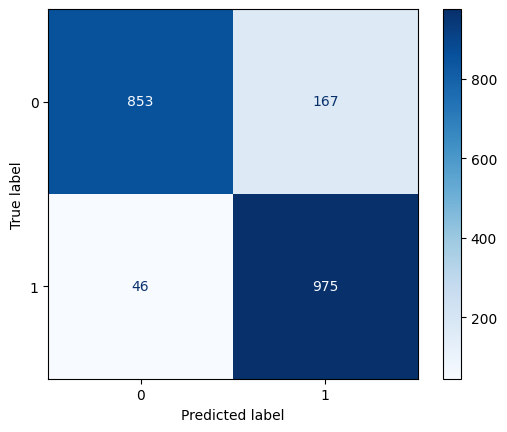

Validation Accuracy: 0.895639392454679
Validation Loss: 0.24753921336658774


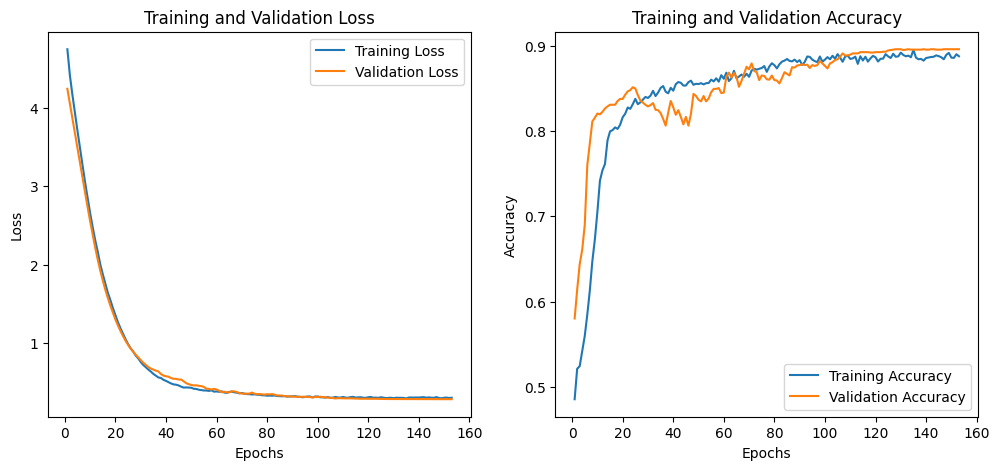

In [ ]:
from tensorflow.keras.optimizers import AdamW

# Initializing the model
model = TabularXception.from_config(data_config, model_config, name='tab_xception')
model.compile(loss='categorical_crossentropy', optimizer="adam", metrics=['accuracy'])

try:
    # Training the model
    history = model.fit(data_train, validation_data=data_valid, callbacks=get_callbacks(), epochs=MAX_EPOCHS)

    # Save training history
    history_all = {
        'train_loss': history.history['loss'],
        'val_loss': history.history['val_loss'],
        'train_accuracy': history.history['accuracy'],
        'val_accuracy': history.history['val_accuracy']
    }

    # Predictions
    preds = model.predict(data_valid)

        # Convert predictions and true labels to classes
    y_pred = np.argmax(preds, axis=1)
    y_true = np.argmax(y_valid.values, axis=1)

    # Compute confusion matrix
    cm = confusion_matrix(y_true, y_pred)

    # Plot confusion matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.show()

    # Compute accuracy and log loss
    accuracy = accuracy_score(y_true, y_pred)
    loss = log_loss(y_valid, preds)

    print(f'Validation Accuracy: {accuracy}')
    print(f'Validation Loss: {loss}')

    # Plot training and validation accuracy and loss
    epochs = range(1, len(history_all['train_loss']) + 1)

    plt.figure(figsize=(12, 5))

    # Plot loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history_all['train_loss'], label='Training Loss')
    plt.plot(epochs, history_all['val_loss'], label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    # Plot accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history_all['train_accuracy'], label='Training Accuracy')
    plt.plot(epochs, history_all['val_accuracy'], label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.show()

except Exception as e:
    print(f"An error occurred during model training: {e}")



In [ ]:
# Display classification report
print("Classification Report:")
print(classification_report(y_true, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.84      0.89      1020
           1       0.85      0.95      0.90      1021

    accuracy                           0.90      2041
   macro avg       0.90      0.90      0.90      2041
weighted avg       0.90      0.90      0.90      2041

